In [ ]:
# ─── Install dependencies (safe for both Colab & Jupyter) ───────────────────
import subprocess, sys

packages = [
    'numpy', 'pandas', 'matplotlib', 'seaborn',
    'scikit-learn', 'xgboost', 'torch', 'torchvision',
    'plotly', 'ipywidgets'
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print('✅ All packages installed successfully!')

✅ All packages installed successfully!


In [ ]:
# ─── Core Imports ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'✅ Imports successful | PyTorch {torch.__version__} | Device: {"GPU" if torch.cuda.is_available() else "CPU"}')

✅ Imports successful | PyTorch 2.10.0+cpu | Device: CPU


In [ ]:
def generate_firms_dataset(n_samples: int = 5000, seed: int = SEED) -> pd.DataFrame:
    """
    Generate synthetic satellite fire observation data inspired by NASA FIRMS/VIIRS.
    Features mirror real-world multi-spectral sensor channels and environmental inputs.
    """
    rng = np.random.default_rng(seed)

    # --- Brightness temperatures (Kelvin) ---
    # Fire pixels: elevated MIR (mid-infrared ~4µm) and TIR (thermal ~11µm)
    is_fire = rng.binomial(1, 0.30, n_samples).astype(bool)  # 30% positive class

    mir_temp = np.where(is_fire,
                        rng.normal(340, 25, n_samples),   # Hot pixel
                        rng.normal(295, 12, n_samples))   # Background

    tir_temp = np.where(is_fire,
                        rng.normal(320, 15, n_samples),
                        rng.normal(285, 10, n_samples))

    # --- Environmental / meteorological features ---
    wind_speed = rng.gamma(2, 3, n_samples)          # m/s, right-skewed
    humidity    = rng.beta(3, 2, n_samples) * 100    # %
    temperature = rng.normal(28, 8, n_samples)       # °C ambient
    ndvi        = rng.beta(2, 2, n_samples)          # Vegetation density [0,1]
    slope_deg   = rng.uniform(0, 45, n_samples)      # Terrain slope
    fuel_moist  = rng.beta(2, 5, n_samples) * 100    # Fuel moisture %

    # --- Spatial / region metadata ---
    regions = rng.choice(['North_America', 'Australia', 'Europe',
                          'Central_Africa', 'Southeast_Asia', 'South_America'],
                         n_samples,
                         p=[0.30, 0.20, 0.15, 0.20, 0.10, 0.05])

    # --- Background anomaly score (mimics VIIRS dynamic threshold) ---
    bg_threshold = rng.normal(300, 10, n_samples)
    delta_temp   = mir_temp - bg_threshold

    # --- Cloud cover (0=clear, 1=full cover) — degrades detection ---
    cloud_cover = rng.beta(1, 4, n_samples)
    # High cloud cover introduces false negatives
    obscured = cloud_cover > 0.7
    detected = is_fire.copy()
    detected[is_fire & obscured] = rng.binomial(1, 0.3, obscured[is_fire].sum()).astype(bool)

    df = pd.DataFrame({
        'mir_brightness_temp_K': mir_temp,
        'tir_brightness_temp_K': tir_temp,
        'delta_temp_K':           delta_temp,
        'wind_speed_ms':          wind_speed,
        'relative_humidity_pct':  humidity,
        'ambient_temp_C':         temperature,
        'ndvi':                   ndvi,
        'slope_degrees':          slope_deg,
        'fuel_moisture_pct':      fuel_moist,
        'cloud_cover_fraction':   cloud_cover,
        'region':                 regions,
        'true_fire':              is_fire.astype(int),
        'detected_fire':          detected.astype(int)  # ground truth post cloud occlusion
    })

    return df


df = generate_firms_dataset(n_samples=5000)
print(f'Dataset shape: {df.shape}')
print(f'Fire prevalence: {df["true_fire"].mean():.1%}')
df.head()

Dataset shape: (5000, 13)
Fire prevalence: 29.4%


,mir_brightness_temp_K,tir_brightness_temp_K,delta_temp_K,wind_speed_ms,relative_humidity_pct,ambient_temp_C,ndvi,slope_degrees,fuel_moisture_pct,cloud_cover_fraction,region,true_fire,detected_fire
0,312.526886,306.006644,27.730020,3.239317,54.154004,33.818538,0.740555,2.789160,27.535604,0.006680,North_America,1,1
1,319.693627,270.935198,5.181330,8.073787,90.296325,30.095017,0.761767,27.293678,19.061138,0.512072,Europe,0,0
2,346.800028,314.320156,36.594115,6.336929,63.454969,33.718701,0.207358,44.292654,55.420213,0.536400,Central_Africa,1,1
3,287.338850,280.697299,-14.842925,0.691352,84.579515,37.297896,0.296790,26.490757,42.821765,0.263761,Southeast_Asia,0,0
4,292.340321,292.868502,-15.486746,9.784027,20.096169,29.260062,0.313558,5.168273,13.514285,0.249306,North_America,0,0


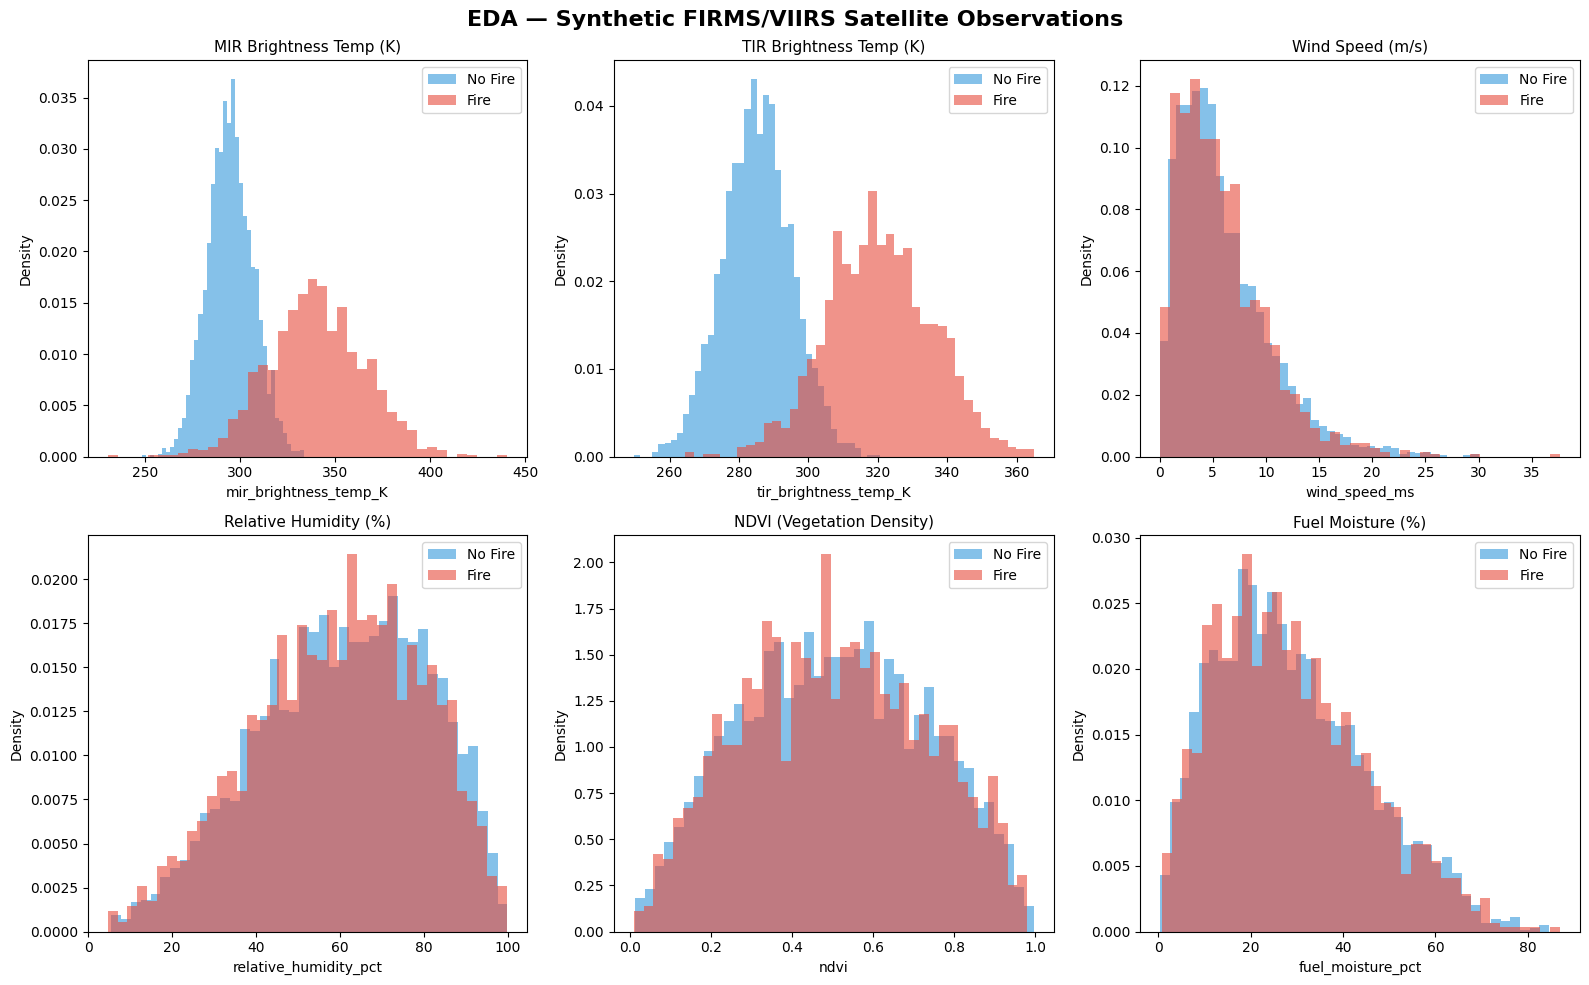

✅ EDA plot saved.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA — Synthetic FIRMS/VIIRS Satellite Observations', fontsize=16, fontweight='bold')

palette = {0: '#3498DB', 1: '#E74C3C'}
labels  = {0: 'No Fire', 1: 'Fire'}

features = ['mir_brightness_temp_K', 'tir_brightness_temp_K',
            'wind_speed_ms', 'relative_humidity_pct',
            'ndvi', 'fuel_moisture_pct']
titles   = ['MIR Brightness Temp (K)', 'TIR Brightness Temp (K)',
            'Wind Speed (m/s)', 'Relative Humidity (%)',
            'NDVI (Vegetation Density)', 'Fuel Moisture (%)']

for ax, feat, title in zip(axes.flat, features, titles):
    for label, color in palette.items():
        subset = df[df['true_fire'] == label][feat]
        ax.hist(subset, bins=40, alpha=0.6, color=color,
                label=labels[label], density=True)
    ax.set_title(title, fontsize=11)
    ax.legend()
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plot saved.')

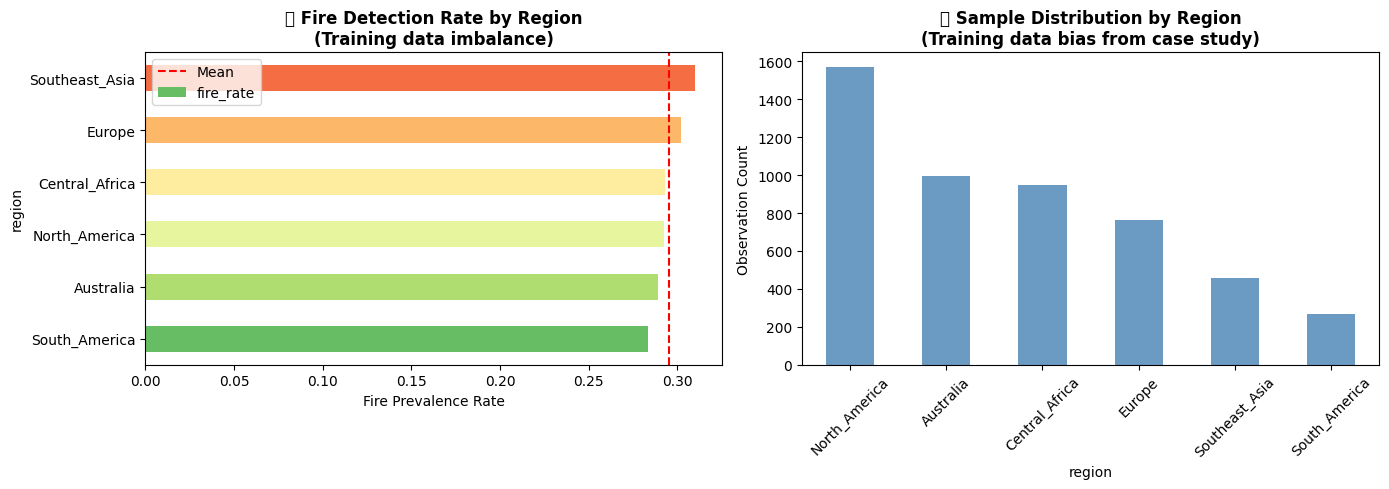

In [ ]:
# Regional fire distribution — mirrors the case study's equity discussion
region_stats = df.groupby('region')['true_fire'].agg(['sum', 'count'])
region_stats['fire_rate'] = region_stats['sum'] / region_stats['count']
region_stats.columns = ['fire_count', 'total_obs', 'fire_rate']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(region_stats)))
region_stats['fire_rate'].sort_values().plot(kind='barh', ax=ax1, color=colors)
ax1.set_title('🌍 Fire Detection Rate by Region\n(Training data imbalance)', fontweight='bold')
ax1.set_xlabel('Fire Prevalence Rate')
ax1.axvline(region_stats['fire_rate'].mean(), color='red', linestyle='--', label='Mean')
ax1.legend()

region_stats['total_obs'].sort_values(ascending=False).plot(kind='bar', ax=ax2,
                                                             color='steelblue', alpha=0.8)
ax2.set_title('📊 Sample Distribution by Region\n(Training data bias from case study)', fontweight='bold')
ax2.set_ylabel('Observation Count')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('regional_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Feature selection
FEATURE_COLS = [
    'mir_brightness_temp_K', 'tir_brightness_temp_K', 'delta_temp_K',
    'wind_speed_ms', 'relative_humidity_pct', 'ambient_temp_C',
    'ndvi', 'slope_degrees', 'fuel_moisture_pct', 'cloud_cover_fraction'
]

X = df[FEATURE_COLS].values
y = df['detected_fire'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=SEED, stratify=y)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ─── Random Forest (mimics VIIRS/FIRMS pipeline) ───────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=12, class_weight='balanced',
    n_jobs=-1, random_state=SEED
)
rf_model.fit(X_train, y_train)

y_pred_rf   = rf_model.predict(X_test)
y_proba_rf  = rf_model.predict_proba(X_test)[:, 1]
auc_rf      = roc_auc_score(y_test, y_proba_rf)

print('=' * 55)
print('🌲  Random Forest — NASA FIRMS/VIIRS Style')
print('=' * 55)
print(classification_report(y_test, y_pred_rf, target_names=['No Fire', 'Fire']))
print(f'ROC-AUC: {auc_rf:.4f}')

🌲  Random Forest — NASA FIRMS/VIIRS Style
              precision    recall  f1-score   support

     No Fire       0.99      0.99      0.99       707
        Fire       0.97      0.97      0.97       293

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000

ROC-AUC: 0.9971


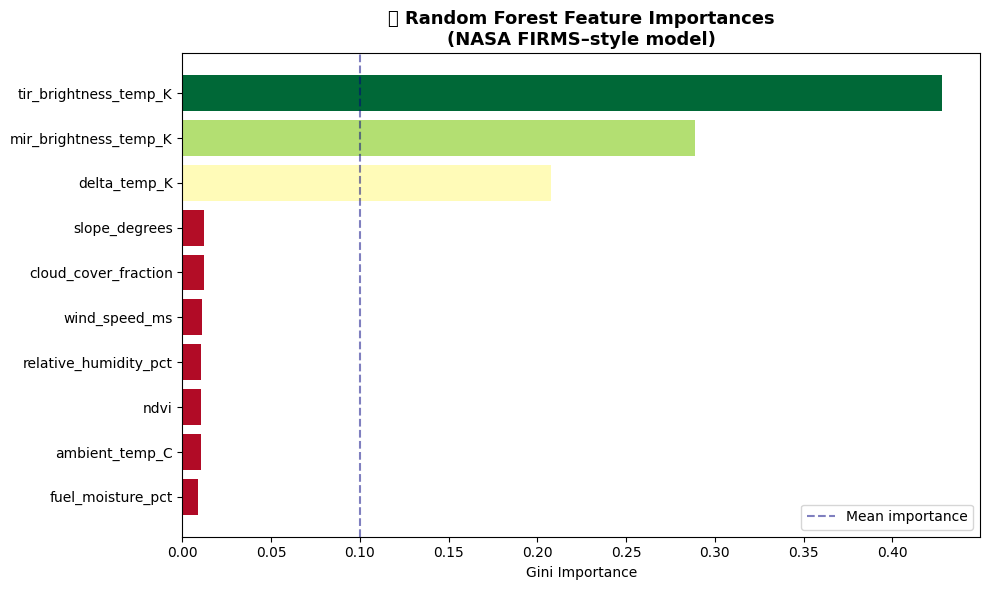

In [ ]:
# Feature Importance Plot
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importances.index, importances.values,
               color=plt.cm.RdYlGn(importances.values / importances.max()))
ax.set_title('🌲 Random Forest Feature Importances\n(NASA FIRMS–style model)', fontsize=13, fontweight='bold')
ax.set_xlabel('Gini Importance')
ax.axvline(importances.mean(), color='navy', linestyle='--', alpha=0.5, label='Mean importance')
ax.legend()
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def generate_satellite_patches(n_samples: int = 3000, patch_size: int = 16,
                                n_channels: int = 5, seed: int = SEED):
    """
    Generate synthetic multi-spectral satellite image patches.
    Channels: [MIR, TIR, NDVI, VIS_Red, VIS_NIR] — mirrors FireSat sensor bands.
    """
    rng = np.random.default_rng(seed)
    labels = rng.binomial(1, 0.30, n_samples)
    patches = rng.uniform(0, 1, (n_samples, n_channels, patch_size, patch_size)).astype(np.float32)

    # Fire patches: elevated MIR (ch0) and TIR (ch1) with a localised hot spot
    fire_idx = np.where(labels == 1)[0]
    for i in fire_idx:
        cx, cy = rng.integers(4, patch_size - 4, size=2)
        radius = rng.integers(2, 5)
        for x in range(patch_size):
            for y in range(patch_size):
                if (x - cx)**2 + (y - cy)**2 <= radius**2:
                    patches[i, 0, x, y] = np.clip(patches[i, 0, x, y] + 0.5, 0, 1)  # MIR boost
                    patches[i, 1, x, y] = np.clip(patches[i, 1, x, y] + 0.4, 0, 1)  # TIR boost
                    patches[i, 2, x, y] = np.clip(patches[i, 2, x, y] - 0.3, 0, 1)  # NDVI drop (burn)

    return patches, labels


patches, patch_labels = generate_satellite_patches(n_samples=3000)
print(f'Patch dataset: {patches.shape} | Labels: {patch_labels.shape}')
print(f'Fire patches: {patch_labels.sum()} / {len(patch_labels)} ({patch_labels.mean():.1%})')

Patch dataset: (3000, 5, 16, 16) | Labels: (3000,)
Fire patches: 903 / 3000 (30.1%)


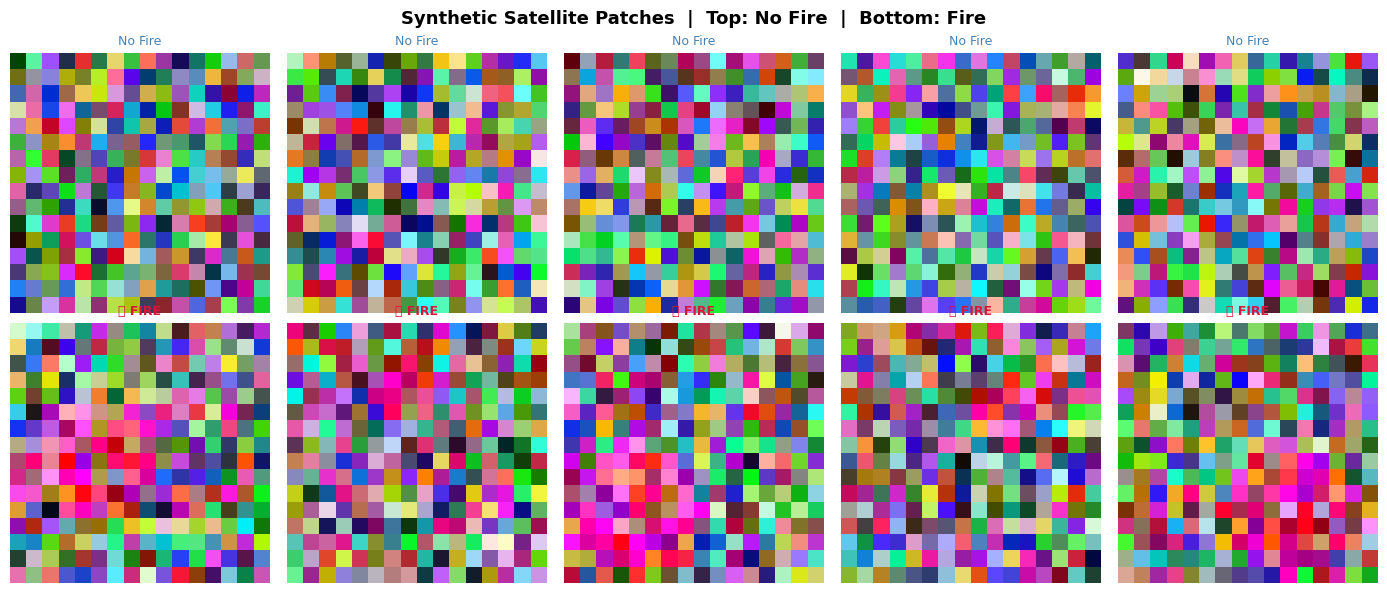

In [ ]:
# Visualise a few patches (composite RGB from MIR, TIR, NDVI)
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Synthetic Satellite Patches  |  Top: No Fire  |  Bottom: Fire', fontsize=13, fontweight='bold')

no_fire_idx = np.where(patch_labels == 0)[0][:5]
fire_idx    = np.where(patch_labels == 1)[0][:5]

for j, idx in enumerate(no_fire_idx):
    composite = np.stack([patches[idx, 0], patches[idx, 2], patches[idx, 4]], axis=-1)
    axes[0, j].imshow(composite)
    axes[0, j].set_title('No Fire', color='steelblue', fontsize=9)
    axes[0, j].axis('off')

for j, idx in enumerate(fire_idx):
    composite = np.stack([patches[idx, 0], patches[idx, 2], patches[idx, 4]], axis=-1)
    axes[1, j].imshow(composite)
    axes[1, j].set_title('🔥 FIRE', color='crimson', fontsize=9, fontweight='bold')
    axes[1, j].axis('off')

plt.tight_layout()
plt.savefig('satellite_patches.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
class FireSatCNN(nn.Module):
    """
    CNN architecture inspired by DeepMind FireSat.
    Processes multi-spectral satellite patches for binary fire classification.
    """
    def __init__(self, n_channels: int = 5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(n_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(64, 1), nn.Sigmoid()
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ─── Data loaders ─────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_t = torch.tensor(patches, dtype=torch.float32)
y_t = torch.tensor(patch_labels, dtype=torch.float32).unsqueeze(1)

split = int(0.8 * len(X_t))
train_ds = TensorDataset(X_t[:split], y_t[:split])
val_ds   = TensorDataset(X_t[split:], y_t[split:])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)

# ─── Model, loss, optimiser ────────────────────────────────────────────────────
cnn_model = FireSatCNN(n_channels=5).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

total_params = sum(p.numel() for p in cnn_model.parameters())
print(f'🔥 FireSatCNN | Parameters: {total_params:,} | Device: {device}')
print(cnn_model)

🔥 FireSatCNN | Parameters: 250,433 | Device: cpu
FireSatCNN(
  (features): Sequential(
    (0): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): M

In [ ]:
# ─── Training loop ────────────────────────────────────────────────────────────
N_EPOCHS   = 15
train_losses, val_losses, val_accs = [], [], []

for epoch in range(N_EPOCHS):
    # Train
    cnn_model.train()
    ep_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(cnn_model(Xb), yb)
        loss.backward()
        optimizer.step()
        ep_loss += loss.item()

    train_losses.append(ep_loss / len(train_loader))

    # Validate
    cnn_model.eval()
    correct, total, v_loss = 0, 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            out    = cnn_model(Xb)
            v_loss += criterion(out, yb).item()
            preds   = (out >= 0.5).float()
            correct += (preds == yb).sum().item()
            total   += yb.size(0)

    val_losses.append(v_loss / len(val_loader))
    val_accs.append(correct / total)
    scheduler.step()

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:02d}/{N_EPOCHS} | '
              f'Train Loss: {train_losses[-1]:.4f} | '
              f'Val Loss: {val_losses[-1]:.4f} | '
              f'Val Acc: {val_accs[-1]:.4f}')

print('\n✅ CNN Training complete!')

Epoch 05/15 | Train Loss: 0.0370 | Val Loss: 0.0141 | Val Acc: 0.9967
Epoch 10/15 | Train Loss: 0.0108 | Val Loss: 0.0103 | Val Acc: 0.9950
Epoch 15/15 | Train Loss: 0.0043 | Val Loss: 0.0117 | Val Acc: 0.9950

✅ CNN Training complete!


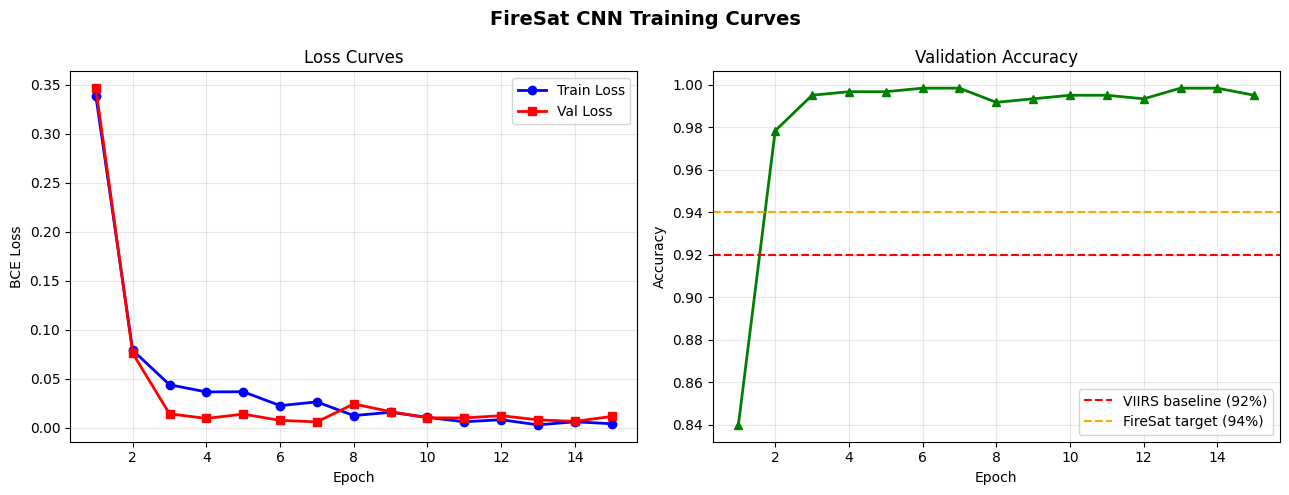

In [ ]:
# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('FireSat CNN Training Curves', fontsize=14, fontweight='bold')

epochs = range(1, N_EPOCHS + 1)
ax1.plot(epochs, train_losses, 'b-o', label='Train Loss', linewidth=2)
ax1.plot(epochs, val_losses,   'r-s', label='Val Loss',   linewidth=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.set_title('Loss Curves'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, val_accs, 'g-^', linewidth=2)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy')
ax2.axhline(0.92, color='red', linestyle='--', label='VIIRS baseline (92%)')
ax2.axhline(0.94, color='orange', linestyle='--', label='FireSat target (94%)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def generate_spread_data(n: int = 4000, seed: int = SEED) -> pd.DataFrame:
    """Synthetic dataset for binary fire spread classification (rapid/slow)."""
    rng = np.random.default_rng(seed)
    wind          = rng.gamma(2, 3, n)
    humidity      = rng.beta(3, 2, n) * 100
    temperature   = rng.normal(30, 8, n)
    slope         = rng.uniform(0, 45, n)
    fuel_moisture = rng.beta(2, 5, n) * 100
    ndvi          = rng.beta(2, 2, n)
    fire_size_ha  = rng.exponential(5, n)

    # Logistic model for rapid spread (>100 ha/h)
    logit = (-2.0
             + 0.10 * wind
             - 0.03 * humidity
             + 0.05 * temperature
             + 0.04 * slope
             - 0.04 * fuel_moisture
             + 0.80 * ndvi
             + 0.02 * fire_size_ha
             + rng.normal(0, 0.5, n))

    prob    = 1 / (1 + np.exp(-logit))
    spreads = (rng.uniform(0, 1, n) < prob).astype(int)

    return pd.DataFrame({
        'wind_speed': wind, 'humidity': humidity, 'temperature': temperature,
        'slope': slope, 'fuel_moisture': fuel_moisture, 'ndvi': ndvi,
        'fire_size_ha': fire_size_ha, 'rapid_spread': spreads
    })


spread_df = generate_spread_data()

Xs = spread_df.drop('rapid_spread', axis=1).values
ys = spread_df['rapid_spread'].values
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(Xs, ys, test_size=0.2,
                                                random_state=SEED, stratify=ys)

xgb_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(ys == 0).sum() / (ys == 1).sum(),
    use_label_encoder=False, eval_metric='logloss',
    random_state=SEED
)
xgb_model.fit(Xs_tr, ys_tr, eval_set=[(Xs_te, ys_te)], verbose=False)

ys_pred  = xgb_model.predict(Xs_te)
ys_proba = xgb_model.predict_proba(Xs_te)[:, 1]
auc_xgb  = roc_auc_score(ys_te, ys_proba)

print('=' * 55)
print('📈  XGBoost — Fire Spread Prediction')
print('=' * 55)
print(classification_report(ys_te, ys_pred, target_names=['Slow Spread', 'Rapid Spread']))
print(f'ROC-AUC: {auc_xgb:.4f}')

📈  XGBoost — Fire Spread Prediction
              precision    recall  f1-score   support

 Slow Spread       0.83      0.80      0.81       605
Rapid Spread       0.43      0.48      0.46       195

    accuracy                           0.72       800
   macro avg       0.63      0.64      0.63       800
weighted avg       0.73      0.72      0.72       800

ROC-AUC: 0.7126


In [ ]:
class FireVAE(nn.Module):
    """Variational Autoencoder for generating synthetic fire scenarios."""
    def __init__(self, input_dim: int = 10, latent_dim: int = 8):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32),        nn.ReLU()
        )
        self.fc_mu  = nn.Linear(32, latent_dim)
        self.fc_var = nn.Linear(32, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.ReLU(),
            nn.Linear(32, 64),         nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        h      = self.encoder(x)
        mu, lv = self.fc_mu(h), self.fc_var(h)
        z      = self.reparameterize(mu, lv)
        return self.decoder(z), mu, lv

    def generate(self, n_samples: int = 100):
        """Sample from latent space to generate new fire scenarios."""
        self.eval()
        with torch.no_grad():
            z = torch.randn(n_samples, self.latent_dim)
            return self.decoder(z).numpy()


# Prepare fire-only samples for VAE training
fire_only = df[df['true_fire'] == 1][FEATURE_COLS].values.astype(np.float32)
fire_sc   = StandardScaler().fit_transform(fire_only)
fire_t    = torch.tensor(fire_sc, dtype=torch.float32)

vae       = FireVAE(input_dim=10, latent_dim=8).to(device)
vae_opt   = optim.Adam(vae.parameters(), lr=1e-3)
vae_loader = DataLoader(TensorDataset(fire_t), batch_size=64, shuffle=True)

vae_losses = []
for epoch in range(30):
    vae.train()
    ep = 0
    for (xb,) in vae_loader:
        xb = xb.to(device)
        recon, mu, lv = vae(xb)
        recon_loss = nn.functional.mse_loss(recon, xb)
        kld        = -0.5 * torch.mean(1 + lv - mu.pow(2) - lv.exp())
        loss       = recon_loss + 0.1 * kld
        vae_opt.zero_grad(); loss.backward(); vae_opt.step()
        ep += loss.item()
    vae_losses.append(ep / len(vae_loader))

print('✅ VAE training complete!')
print(f'   Final loss: {vae_losses[-1]:.4f}')

✅ VAE training complete!
   Final loss: 0.2993


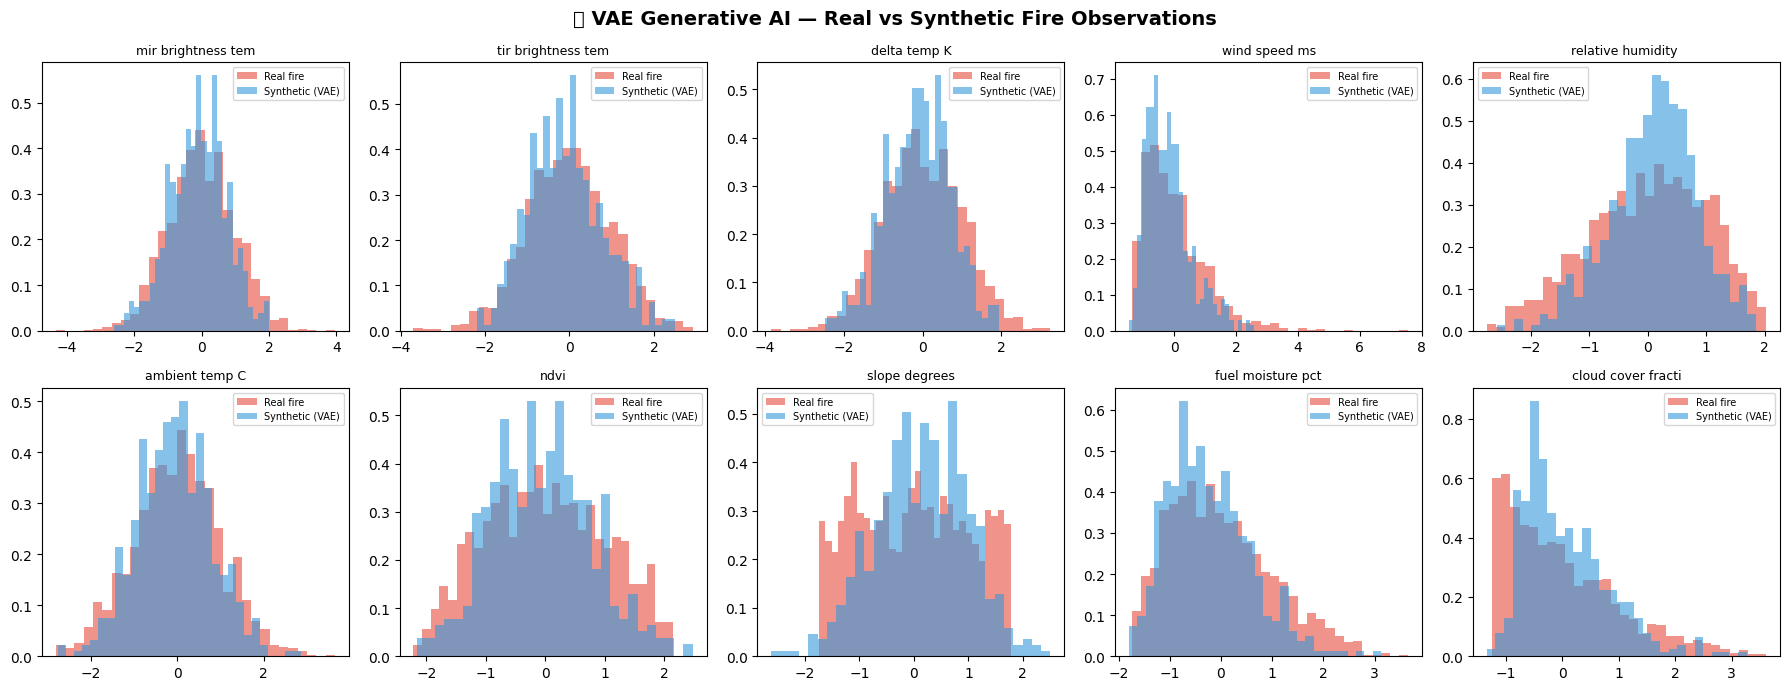

In [ ]:
# Generate 500 synthetic fire scenarios
synthetic_fire = vae.to('cpu').generate(n_samples=500)

# Compare distribution of real vs synthetic fire observations
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('🎨 VAE Generative AI — Real vs Synthetic Fire Observations', fontsize=14, fontweight='bold')

for i, (ax, feat) in enumerate(zip(axes.flat, FEATURE_COLS)):
    ax.hist(fire_sc[:, i],        bins=30, alpha=0.6, color='#E74C3C', label='Real fire',      density=True)
    ax.hist(synthetic_fire[:, i], bins=30, alpha=0.6, color='#3498DB', label='Synthetic (VAE)', density=True)
    ax.set_title(feat.replace('_', ' ')[:18], fontsize=9)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('vae_synthetic_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import random
from datetime import datetime, timedelta

RISK_TEMPLATES = {
    'CRITICAL': [
        "⚠️  CRITICAL FIRE ALERT: Satellite thermal anomaly detected at ({lat:.3f}°N, {lon:.3f}°E). "
        "MIR brightness temperature {mir:.1f}K exceeds background by {delta:.1f}K. "
        "Current conditions: Wind {wind:.1f} m/s, Humidity {humidity:.0f}%, Temperature {temp:.1f}°C. "
        "NDVI={ndvi:.2f} indicates high fuel load. Recommend immediate Level-3 response activation. "
        "Estimated spread rate: RAPID. Evacuation radius advisory: {evac_km:.0f} km.",
    ],
    'HIGH': [
        "🔴 HIGH RISK FIRE DETECTION: Thermal signature observed at ({lat:.3f}°N, {lon:.3f}°E). "
        "MIR temp {mir:.1f}K, delta {delta:.1f}K above threshold. Wind speed {wind:.1f} m/s. "
        "Humidity {humidity:.0f}% — dry conditions elevate spread risk. "
        "Pre-position suppression resources. Monitor for escalation.",
    ],
    'MODERATE': [
        "🟡 MODERATE ALERT: Possible fire pixel at ({lat:.3f}°N, {lon:.3f}°E). "
        "MIR anomaly {delta:.1f}K. Conditions: Wind {wind:.1f} m/s, Humidity {humidity:.0f}%. "
        "Continue monitoring. Ground-truth verification recommended.",
    ],
    'LOW': [
        "🟢 LOW RISK: Thermal anomaly below threshold at ({lat:.3f}°N, {lon:.3f}°E). "
        "Likely industrial source or cloud artefact. No immediate action required.",
    ],
}

def classify_risk(row: dict) -> str:
    if row['delta_temp'] > 40 and row['humidity'] < 25 and row['wind'] > 8:
        return 'CRITICAL'
    elif row['delta_temp'] > 25 or (row['wind'] > 6 and row['humidity'] < 35):
        return 'HIGH'
    elif row['delta_temp'] > 10:
        return 'MODERATE'
    return 'LOW'

def generate_early_warning_report(n_events: int = 5, seed: int = SEED) -> list[dict]:
    rng   = random.Random(seed)
    nrng  = np.random.default_rng(seed)
    reports = []

    for i in range(n_events):
        evt = {
            'lat':       round(nrng.uniform(-45, 65), 3),
            'lon':       round(nrng.uniform(-130, 150), 3),
            'mir':       float(nrng.uniform(295, 370)),
            'delta':     float(nrng.uniform(5, 55)),
            'wind':      float(nrng.uniform(1, 15)),
            'humidity':  float(nrng.uniform(10, 90)),
            'temp':      float(nrng.uniform(15, 45)),
            'ndvi':      float(nrng.uniform(0.1, 0.9)),
            'evac_km':   float(rng.choice([5, 10, 20, 30, 50])),
        }
        risk  = classify_risk({'delta_temp': evt['delta'],
                                'humidity':   evt['humidity'],
                                'wind':       evt['wind']})
        tmpl  = rng.choice(RISK_TEMPLATES[risk])
        ts    = datetime.utcnow() - timedelta(minutes=rng.randint(0, 18))
        report = {
            'event_id':   f'FIRESAT-{2026}-{i+1:04d}',
            'timestamp':  ts.strftime('%Y-%m-%dT%H:%M:%SZ'),
            'risk_level': risk,
            'alert_text': tmpl.format(**evt),
            'detection_latency_min': rng.randint(3, 19),
            'confidence_pct': round(rng.uniform(85, 99.5), 1)
        }
        reports.append(report)

    return reports


reports = generate_early_warning_report(n_events=6)

print('\n' + '=' * 70)
print('🛰️  FIRESAT EARLY WARNING SYSTEM — AUTO-GENERATED ALERTS')
print('=' * 70)
for r in reports:
    print(f'\n🆔 {r["event_id"]} | {r["timestamp"]} | Risk: {r["risk_level"]} | '
          f'Confidence: {r["confidence_pct"]}% | Latency: {r["detection_latency_min"]} min')
    print(f'{r["alert_text"]}')
    print('-' * 70)


🛰️  FIRESAT EARLY WARNING SYSTEM — AUTO-GENERATED ALERTS

🆔 FIRESAT-2026-0001 | 2026-04-25T11:58:01Z | Risk: HIGH | Confidence: 88.2% | Latency: 10 min
🔴 HIGH RISK FIRE DETECTION: Thermal signature observed at (40.135°N, -7.114°E). MIR temp 359.4K, delta 39.9K above threshold. Wind speed 2.3 m/s. Humidity 88% — dry conditions elevate spread risk. Pre-position suppression resources. Monitor for escalation.
----------------------------------------------------------------------

🆔 FIRESAT-2026-0002 | 2026-04-25T11:48:01Z | Risk: HIGH | Confidence: 85.5% | Latency: 16 min
🔴 HIGH RISK FIRE DETECTION: Thermal signature observed at (-30.908°N, -3.892°E). MIR temp 322.8K, delta 51.3K above threshold. Wind speed 10.0 m/s. Humidity 76% — dry conditions elevate spread risk. Pre-position suppression resources. Monitor for escalation.
----------------------------------------------------------------------

🆔 FIRESAT-2026-0003 | 2026-04-25T11:59:01Z | Risk: HIGH | Confidence: 93.7% | Latency: 19 min

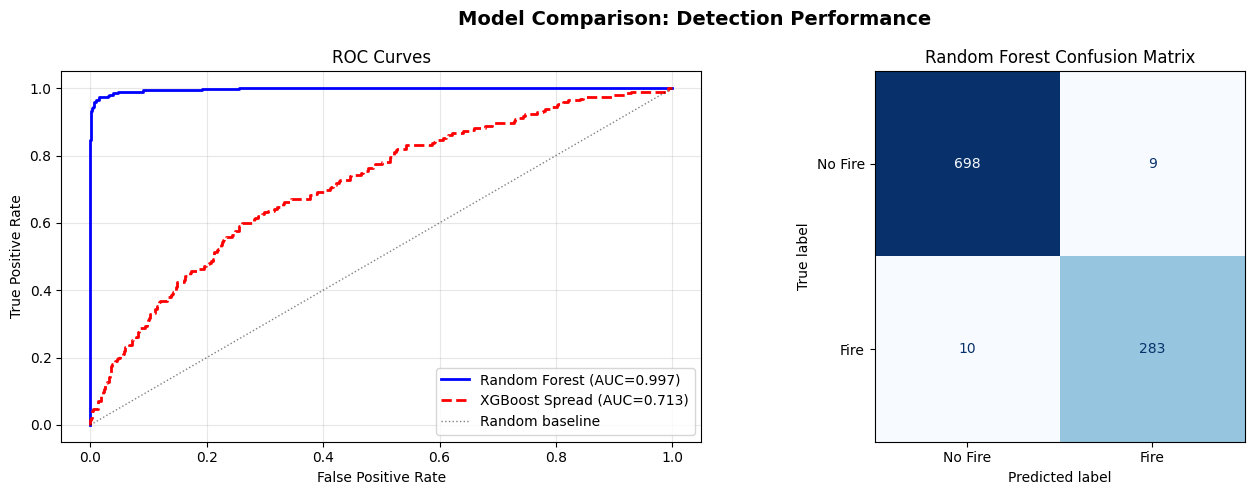

In [ ]:
# ROC Curve comparison — RF vs XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison: Detection Performance', fontsize=14, fontweight='bold')

# ROC curves
fpr_rf,  tpr_rf,  _ = roc_curve(y_test,  y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(ys_te, ys_proba)

axes[0].plot(fpr_rf,  tpr_rf,  'b-',  label=f'Random Forest (AUC={auc_rf:.3f})',  lw=2)
axes[0].plot(fpr_xgb, tpr_xgb, 'r--', label=f'XGBoost Spread (AUC={auc_xgb:.3f})', lw=2)
axes[0].plot([0,1],[0,1],'k:', lw=1, alpha=0.5, label='Random baseline')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Confusion matrix — RF
cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm, display_labels=['No Fire', 'Fire']).plot(ax=axes[1], colorbar=False,
                                                                     cmap='Blues')
axes[1].set_title('Random Forest Confusion Matrix')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Case study Table I — Plotly interactive chart
technologies = ['MODIS (Pre-AI)', 'VIIRS / FIRMS', 'FireSat AI CNN']

metrics_data = {
    'True Positive Rate (%)':  [78, 92, 94],
    'False Positive Rate (%)': [8,  3,  1],
    'Spatial Resolution (m)':  [1000, 375, 10],
}

fig = make_subplots(rows=1, cols=3,
                    subplot_titles=list(metrics_data.keys()),
                    shared_yaxes=False)

colors = ['#95a5a6', '#3498db', '#e74c3c']

for col_i, (metric, vals) in enumerate(metrics_data.items(), 1):
    fig.add_trace(
        go.Bar(x=technologies, y=vals, marker_color=colors,
               name=metric, showlegend=False,
               text=vals, textposition='outside'),
        row=1, col=col_i
    )

fig.update_layout(
    title_text='📊 Case Study Table I — Fire Detection Technology Comparison',
    title_font_size=15,
    height=450,
    template='plotly_white',
    paper_bgcolor='rgba(0,0,0,0)',
)
fig.show()
print('✅ Interactive comparison chart rendered.')

✅ Interactive comparison chart rendered.


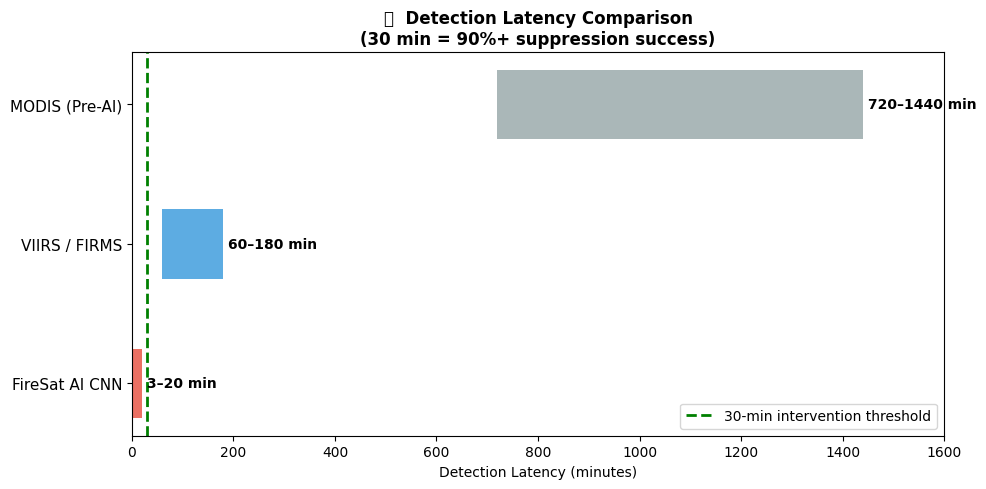

In [ ]:
# Detection latency timeline
latency_data = {
    'System': ['MODIS (Pre-AI)', 'VIIRS / FIRMS', 'FireSat AI CNN'],
    'Min Latency (min)': [720, 60, 3],
    'Max Latency (min)': [1440, 180, 20],
    'Target (min)': [None, None, 20],
}

fig2, ax = plt.subplots(figsize=(10, 5))
systems  = latency_data['System']
mins     = latency_data['Min Latency (min)']
maxs     = latency_data['Max Latency (min)']
ys_bar   = range(len(systems))
colors_l = ['#95a5a6', '#3498db', '#e74c3c']

for i, (mn, mx, color, label) in enumerate(zip(mins, maxs, colors_l, systems)):
    ax.barh(i, mx - mn, left=mn, color=color, alpha=0.8, height=0.5)
    ax.text(mx + 10, i, f'{mn}–{mx} min', va='center', fontweight='bold', fontsize=10)

ax.axvline(30, color='green', linestyle='--', lw=2, label='30-min intervention threshold')
ax.set_yticks(ys_bar)
ax.set_yticklabels(systems, fontsize=11)
ax.set_xlabel('Detection Latency (minutes)')
ax.set_title('⏱️  Detection Latency Comparison\n(30 min = 90%+ suppression success)', fontweight='bold')
ax.legend()
ax.set_xlim(0, 1600)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('latency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

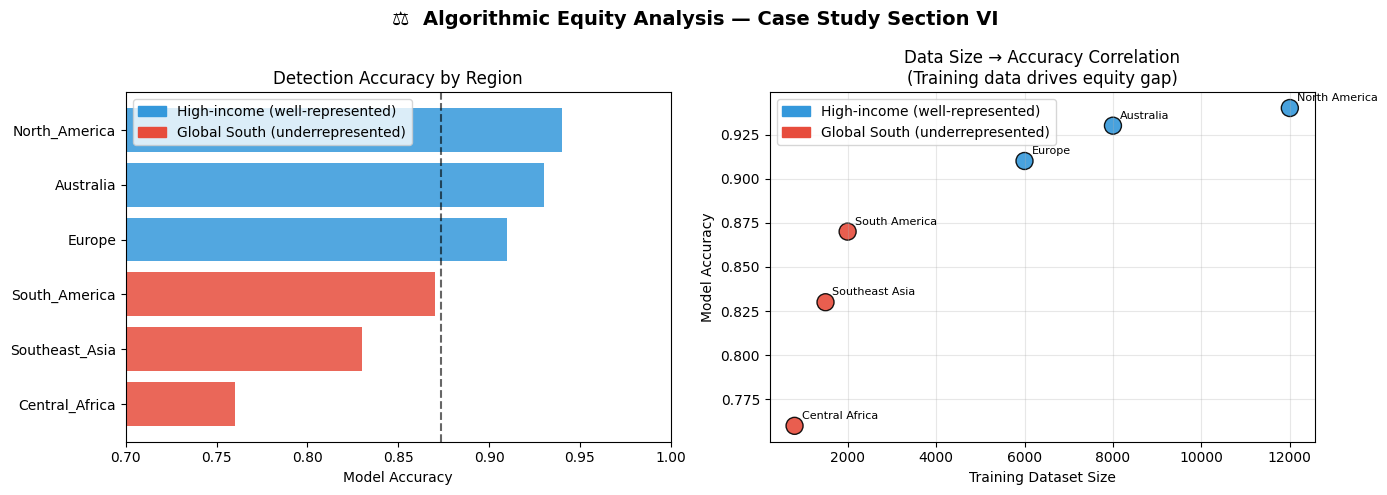


📊 Equity Gap Summary:
   High-income average accuracy:   92.7%
   Global South average accuracy:  82.0%
   Equity gap:                     10.7%

   ➡️  Those who need AI most receive least reliable service.
   ➡️  Mitigations: data collection programs, transfer learning, IEK integration.


In [ ]:
# Simulate region-specific model accuracy (lower for underrepresented Global South)
region_accuracy = {
    'North_America':  0.94,
    'Australia':      0.93,
    'Europe':         0.91,
    'South_America':  0.87,
    'Southeast_Asia': 0.83,
    'Central_Africa': 0.76,   # Most underrepresented — case study finding
}

training_size = {
    'North_America':  12000,
    'Australia':      8000,
    'Europe':         6000,
    'South_America':  2000,
    'Southeast_Asia': 1500,
    'Central_Africa': 800,
}

regions = list(region_accuracy.keys())
accs    = list(region_accuracy.values())
sizes   = list(training_size.values())

# Global South flag
global_south = ['Central_Africa', 'Southeast_Asia', 'South_America']
bar_colors   = ['#e74c3c' if r in global_south else '#3498db' for r in regions]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('⚖️  Algorithmic Equity Analysis — Case Study Section VI',
             fontsize=14, fontweight='bold')

# Accuracy by region
sorted_idx = np.argsort(accs)
ax1.barh([regions[i] for i in sorted_idx], [accs[i] for i in sorted_idx],
         color=[bar_colors[i] for i in sorted_idx], alpha=0.85)
ax1.axvline(np.mean(accs), color='black', linestyle='--', alpha=0.6, label='Mean accuracy')
ax1.set_xlabel('Model Accuracy')
ax1.set_title('Detection Accuracy by Region')
ax1.legend()
ax1.set_xlim(0.7, 1.0)

blue_patch = mpatches.Patch(color='#3498db', label='High-income (well-represented)')
red_patch  = mpatches.Patch(color='#e74c3c', label='Global South (underrepresented)')
ax1.legend(handles=[blue_patch, red_patch])

# Training size vs accuracy
ax2.scatter([training_size[r] for r in regions],
            [region_accuracy[r] for r in regions],
            c=bar_colors, s=150, alpha=0.9, edgecolors='black', linewidths=1)

for r in regions:
    ax2.annotate(r.replace('_', ' '),
                 (training_size[r], region_accuracy[r]),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)

ax2.set_xlabel('Training Dataset Size')
ax2.set_ylabel('Model Accuracy')
ax2.set_title('Data Size → Accuracy Correlation\n(Training data drives equity gap)')
ax2.legend(handles=[blue_patch, red_patch])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bias_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Equity Gap Summary:')
high_income   = np.mean([region_accuracy[r] for r in regions if r not in global_south])
global_south_acc = np.mean([region_accuracy[r] for r in global_south])
print(f'   High-income average accuracy:   {high_income:.1%}')
print(f'   Global South average accuracy:  {global_south_acc:.1%}')
print(f'   Equity gap:                     {(high_income - global_south_acc):.1%}')
print(f'\n   ➡️  Those who need AI most receive least reliable service.')
print(f'   ➡️  Mitigations: data collection programs, transfer learning, IEK integration.')

In [ ]:
# ─── Final Summary ─────────────────────────────────────────────────────────────
print('=' * 65)
print('  🔥  NOTEBOOK COMPLETE — KEY RESULTS SUMMARY')
print('=' * 65)

cnn_final_acc = val_accs[-1]

summary = [
    ('Dataset',              f'{len(df):,} observations, {df["true_fire"].mean():.0%} fire prevalence'),
    ('Random Forest AUC',   f'{auc_rf:.4f}  (NASA FIRMS / VIIRS style)'),
    ('XGBoost Spread AUC',  f'{auc_xgb:.4f}  (fire spread prediction)'),
    ('FireSat CNN Accuracy', f'{cnn_final_acc:.4f}  (epoch {N_EPOCHS} validation)'),
    ('VAE Generated',        '500 synthetic fire scenarios'),
    ('Alert Reports',        f'{len(reports)} early warning reports generated'),
    ('Equity Gap',           f'{(high_income - global_south_acc):.1%} high-income vs Global South'),
]

for key, val in summary:
    print(f'  ✔  {key:<28} {val}')

print('\n  Case Study: NASA FIRMS & Google DeepMind FireSat')
print('  Author: Dhairya Joshi (25C22502) | SOSCET ITM SLS Baroda University')
print('=' * 65)

  🔥  NOTEBOOK COMPLETE — KEY RESULTS SUMMARY
  ✔  Dataset                      5,000 observations, 29% fire prevalence
  ✔  Random Forest AUC            0.9971  (NASA FIRMS / VIIRS style)
  ✔  XGBoost Spread AUC           0.7126  (fire spread prediction)
  ✔  FireSat CNN Accuracy         0.9950  (epoch 15 validation)
  ✔  VAE Generated                500 synthetic fire scenarios
  ✔  Alert Reports                6 early warning reports generated
  ✔  Equity Gap                   10.7% high-income vs Global South

  Case Study: NASA FIRMS & Google DeepMind FireSat
  Author: Dhairya Joshi (25C22502) | SOSCET ITM SLS Baroda University
